In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [2]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [3]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [4]:
knn_model.fit(x_train_smote, y_train_smote)

KNeighborsClassifier()

In [5]:
knn_pred = knn_model.predict(x_test_scaled)

In [6]:
knn_prob = knn_model.predict_proba(x_test_scaled)[:, 1]
print(knn_prob)

[0.  0.4 0.4 0.8 0.  0.  0.  0.6 0.8 0.4 0.4 1.  0.4 0.6 0.  0.  0.  0.
 0.4 0.  0.4 0.4 0.4 0.2 0.8 0.  0.  0.  1.  0.4 0.4 0.6 0.  0.8 0.4 0.
 0.  0.  0.2 1.  0.6 0.  0.  0.8 0.  0.4 0.6 0.4 0.  0.  0.  0.  0.  0.8
 0.2 0.  0.  0.2 0.8 0.  0.  0.  0.4 0.6 0.2 0.4 0.2 0.4 0.4 0.4 0.  0.6
 0.2 0.  0.2 0.8 0.  0.  0.4 0.8 0.8 0.  0.2 0.2 0.2 1.  0.8 0.  0.8 0.2
 0.4 1.  0.6 0.8 0.6 0.4 0.6 0.  0.2 0.  0.6 0.4 0.4 0.  0.  0.8 0.2 0.2
 1.  0.2 0.8 0.  0.  0.2 0.  0.  0.4 0.6 0.4 0.2 0.6 0.6 1.  0.4 0.2 0.
 0.4 0.4 0.  0.2 0.2 0.4 0.2 0.  0.2 0.6 0.4 0.2 0.2 0.4 0.6 0.  0.  0.8
 1.  0.2 0.4 0.2 0.  0.6 0.6 0.4 0.2 0.  0.2 0.  0.  0.2 0.6 0.4 0.  0.6
 0.2 0.8 0.  0.2 0.4 0.  0.2 0.  0.  0.8 0.  0.8 0.  0.8 0.8 0.8 0.4 0.2
 1.  0.4 0.  0.  0.  0.6 0.6 0.6 0.2 0.8 0.8 0.  0.2 0.4 0.2 0.2 0.4 0.6
 0.  0.8 1.  0.2 0.  0.4 0.  0.  0.6 0.4 0.  0.  0.  0.  0.8 0.4 0.  0.6
 0.  0.6 0.2 0.  0.4 0.2 1.  0.  0.6 0.4 0.  0.  0.6 0.2 0.6 0.2 1.  0.2
 0.8 0.  0.2 0.  0.  0.  0.  0.2 0.8 0.8 0.2 0.4 0.4 0

In [7]:
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", round(knn_accuracy, 4))

KNN Accuracy: 0.6667


In [8]:
print("Classification Report\n")
print(classification_report(y_test, knn_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.73      0.78       330
           1       0.22      0.36      0.27        69

    accuracy                           0.67       399
   macro avg       0.53      0.55      0.53       399
weighted avg       0.74      0.67      0.70       399



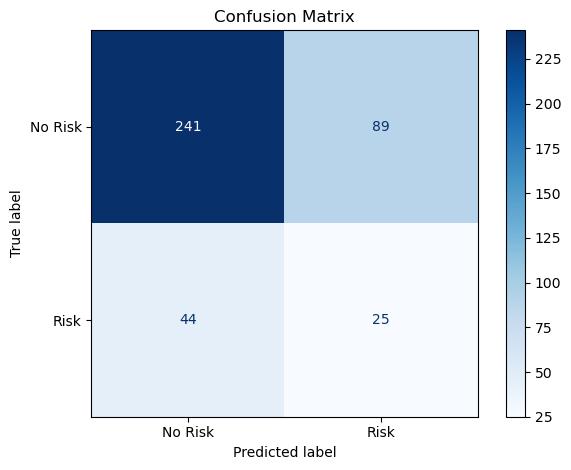

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_pred, display_labels=['No Risk', 'Risk'], cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

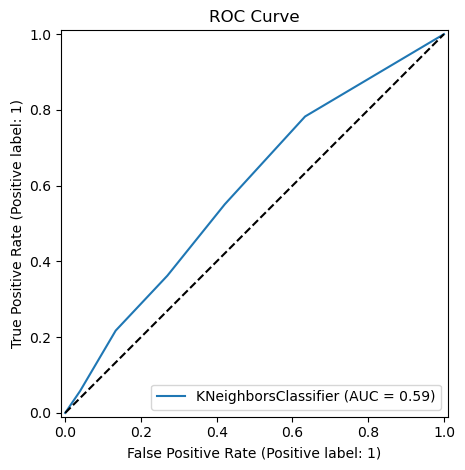

In [10]:
RocCurveDisplay.from_estimator(knn_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

In [11]:
print('ROC-AUC Score:', roc_auc_score(y_test, knn_prob).round(4))

ROC-AUC Score: 0.591


In [12]:
precision = precision_score(y_test, knn_pred)
recall    = recall_score(y_test, knn_pred)
f1        = f1_score(y_test, knn_pred)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Precision: 0.2193
Recall   : 0.3623
F1 Score : 0.2732


In [13]:
train_pred = knn_model.predict(x_train_smote)
print("Train Accuracy:", round(accuracy_score(y_train_smote, train_pred), 4))
print("Test Accuracy :", round(knn_accuracy, 4))

Train Accuracy: 0.91
Test Accuracy : 0.6667


In [14]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(x_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [15]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


In [16]:
best_pred = best_model.predict(x_test_scaled)
best_prob = best_model.predict_proba(x_test_scaled)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test, best_prob).round(4))

Best Model Accuracy: 0.6967
Best Model ROC-AUC : 0.588


In [17]:
cv_scores = cross_val_score(knn_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

CV ROC-AUC Scores: [0.9434 0.9523 0.9636 0.9733 0.9405]
Mean: 0.9546 | Std dev: 0.0124


In [19]:
joblib.dump(knn_model, 'knn_model.pkl')
print("Model saved.")

Model saved.
